# Exploratory Data Analysis

**Dataset:** Sales forecasting (9800 customers)  
**Goal:** To understand the key drivers 

**Tools:** Python · Pandas · Matplotlib · Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv(r"c:\Users\HP USER\Documents\sales_forecasting_app\data\Processed.csv ")

In [3]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Day
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11


In [4]:
df.describe()

,Row ID,Postal Code,Sales,Year,Month,Day
count,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,55276.498571,230.769059,2016.724184,7.818469,15.486837
std,2829.160653,32023.374393,626.651875,1.123984,3.281905,8.753733
min,1.000000,1040.000000,0.444000,2015.000000,1.000000,1.000000
25%,2450.750000,23223.000000,17.248000,2016.000000,5.000000,8.000000
50%,4900.500000,58103.000000,54.490000,2017.000000,9.000000,16.000000
75%,7350.250000,90008.000000,210.605000,2018.000000,11.000000,23.000000
max,9800.000000,99301.000000,22638.480000,2018.000000,12.000000,31.000000


In [5]:
df.shape

(9800, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9800 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
 18  Year    

In [7]:
df["Order Date"] = pd.to_datetime(df['Order Date'])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

## 3. Target Variable Analysis : Sales Distribution

Text(0.5, 1.0, 'Sales Distribution')

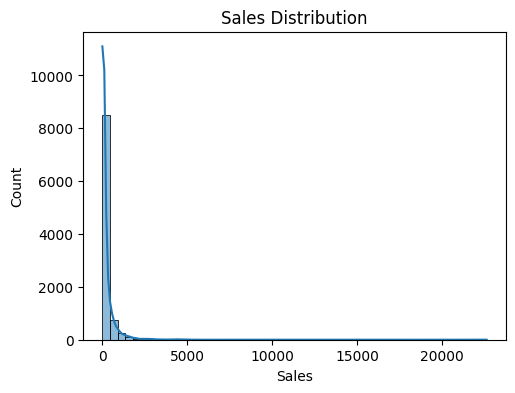

In [9]:
df['Sales'].describe()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Sales Distribution')




The distribution of order-level sales is right-skewed, meaning most transactions are low-to-moderate in value, while a small number of high-value orders pull the average upward. This suggests the revenue isn't evenly spread across orders. A relatively small share of large orders likely contributes to a share of total revenue. 


## 4. Sales Boxplot

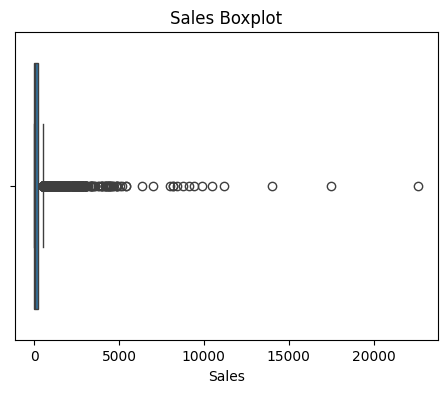

In [10]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,2)
sns.boxplot(x=df['Sales'])
plt.title('Sales Boxplot')
plt.show()



The boxplot shows a number of high-value orders flagged as statistical outliers. They are legitimate large purchases (bulk orders, high-ticket items). These will not be removed from the dataset, instead they can be used to understand what drives the large orders (specific products, customer segments, or times of year) and that could reveal an opportunity to replicate them.


## 5. Daily Total Sales

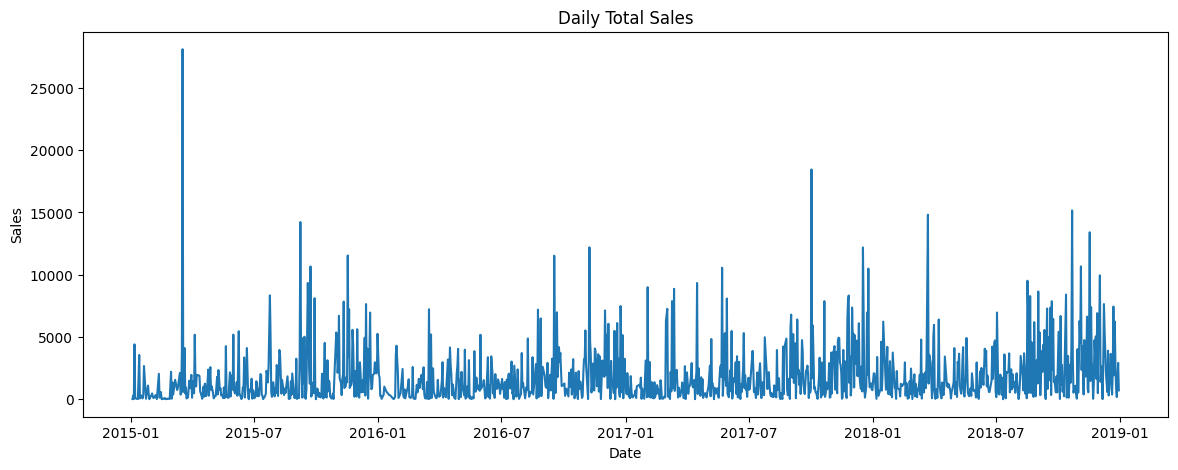

In [11]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.title('Daily Total Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

Day-to-day sales are highly volatile, with sharp spikes and drops rather than a smooth pattern. This is expected at daily bases, individual days are affected by one-off large orders and weekday/weekend effects. Because daily data is too noisy to reveal the underlying business trend, we aggregate to a monthly view for trend analysis.

## 6. Monthly Total Sales

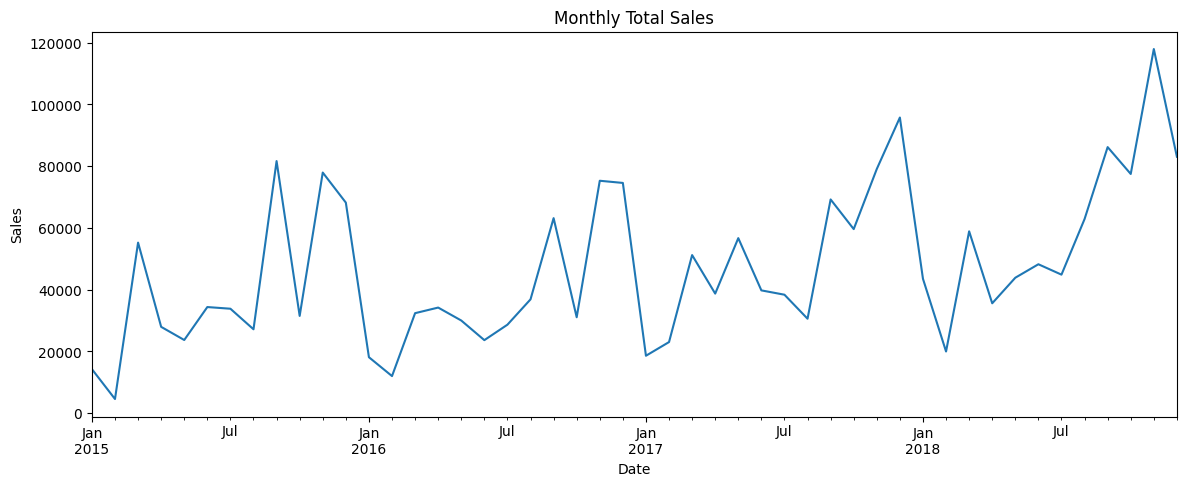

In [12]:
monthly_sales = df.set_index('Order Date').resample('M')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot()
plt.title('Monthly Total Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

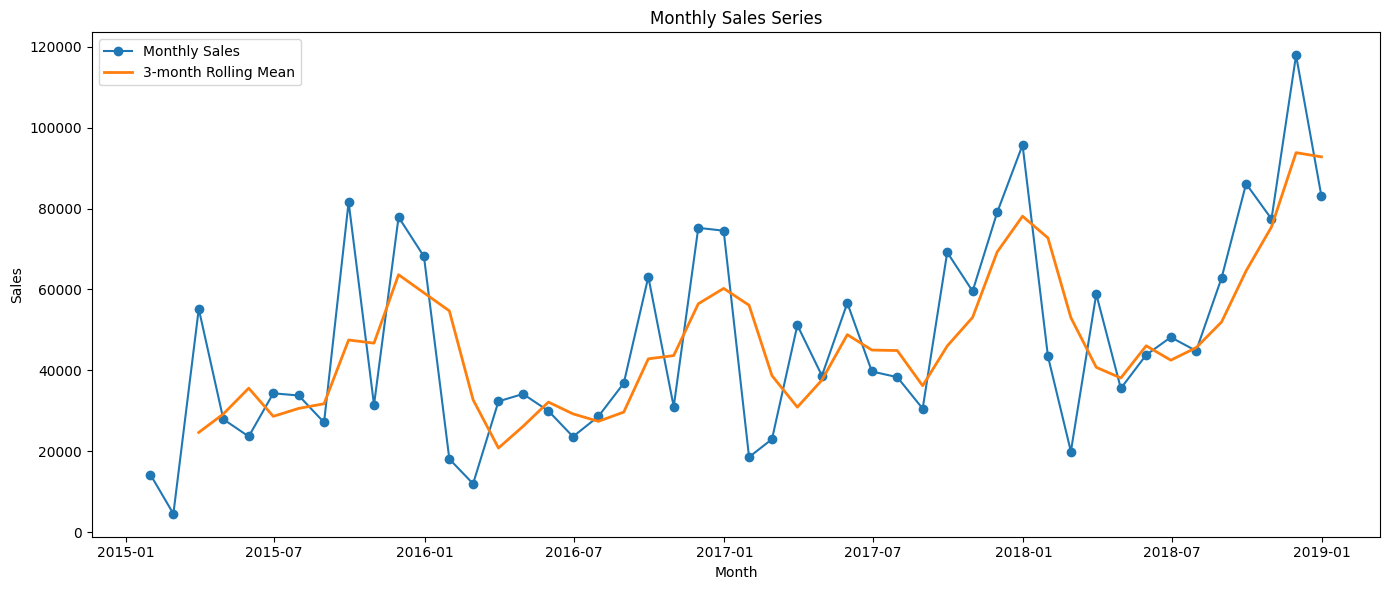

In [13]:
import matplotlib.pyplot as plt

# Assumes you have a monthly Sales series indexed by date, e.g.:
# monthly_sales = df.set_index('Order Date')['Sales'].resample('ME').sum()

rolling_mean = monthly_sales.rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_sales.index, monthly_sales.values,
        marker='o', linewidth=1.5, label='Monthly Sales')

ax.plot(rolling_mean.index, rolling_mean.values,
        linewidth=2, label='3-month Rolling Mean')

ax.set_title('Monthly Sales Series')
ax.set_xlabel('Month')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

At the monthly level, sales fluctuate but show a discernible pattern of peaks and drops recurring across years, rather than random noise. This confirms the business has a seasonal sales cycle, not just random variation; which is the key signal a forecasting model needs to capture.


## 7.Total Sales by Month/Week/Year

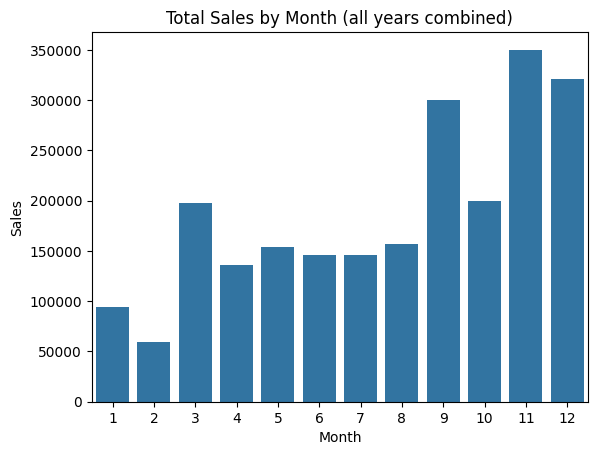

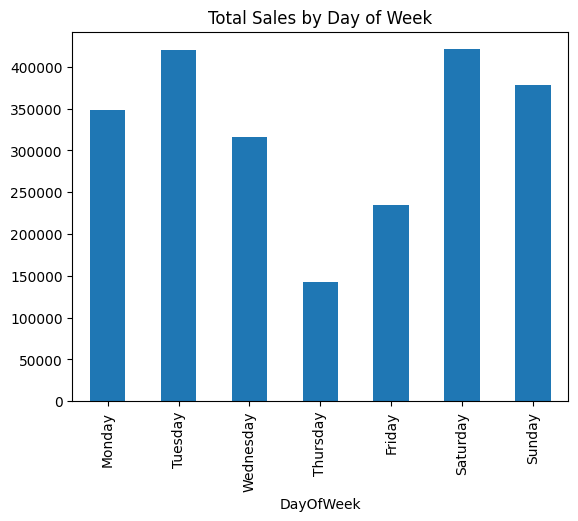

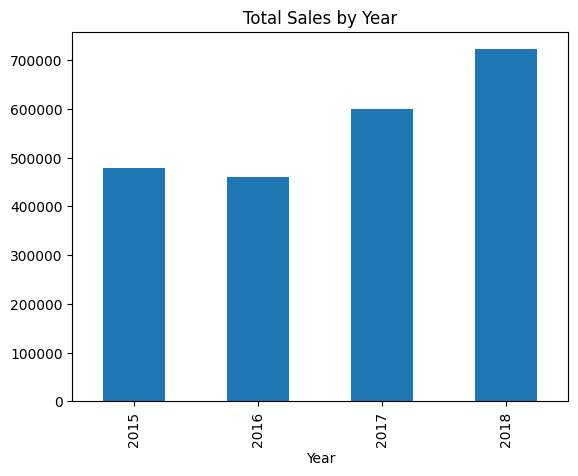

In [14]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['DayOfWeek'] = df['Order Date'].dt.day_name()
# Sales by month, averaged across years
monthly_avg = df.groupby('Month')['Sales'].sum().reset_index()
sns.barplot(x='Month', y='Sales', data=monthly_avg)
plt.title('Total Sales by Month (all years combined)')
plt.show()

# Sales by day of week
dow_avg = df.groupby('DayOfWeek')['Sales'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
dow_avg.plot(kind='bar')
plt.title('Total Sales by Day of Week')
plt.show()

# Year-over-year comparison
yearly = df.groupby('Year')['Sales'].sum()
yearly.plot(kind='bar')
plt.title('Total Sales by Year')
plt.show()


Total Sales by Month:
Sales peak in November and December, with March also standing out as a strong month, while other months are comparatively lower.This points to a clear holiday-season effect (Nov/Dec) alongside a secondary demand spike in March. possibly tied to a promotion, fiscal quarter-end, or seasonal product demand. 

Total Sales by Day Of Week:
Sales are highest on Tuesday and Saturday (roughly equal), followed by Sunday, Monday, Wednesday, Friday, and lowest on Thursday. This is a less typical pattern than pure "weekend-driven" retail. The Tuesday peak in particular is worth, since it may reflect B2B ordering cycles (common in office supply/furniture businesses) alongside weekend consumer buying (Saturday/Sunday). This could inform staffing and promotional timing (e.g., mid-week B2B campaigns).

Total Sales by Year:
Year-over-year, sales are highest in 2018, followed by 2017, then 2015, then 2016. This isn't a clean monotonic growth trend; 2016 dipping below 2015 is worth noting rather than assuming steady year-on-year growth.This means the business has had at least one down year, and any forecast shouldn't blindly assume compounding growtH. 

## 8. Total Sales by Category/Sub-Category/Segment

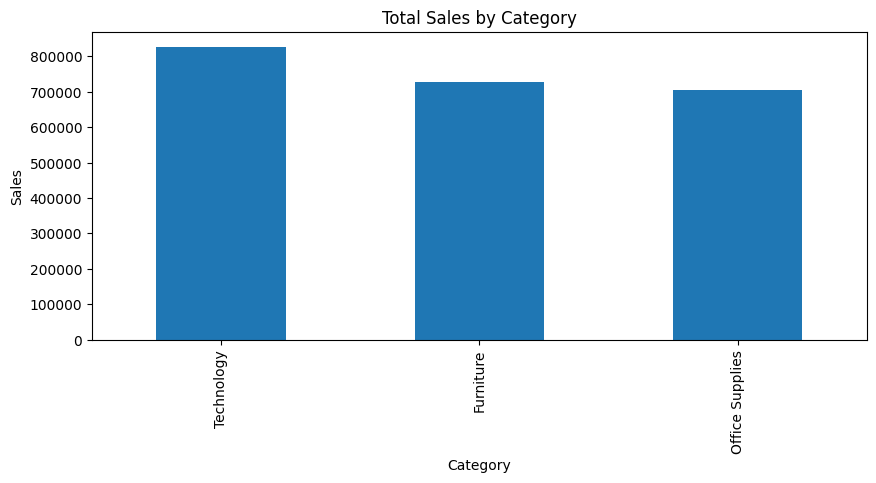

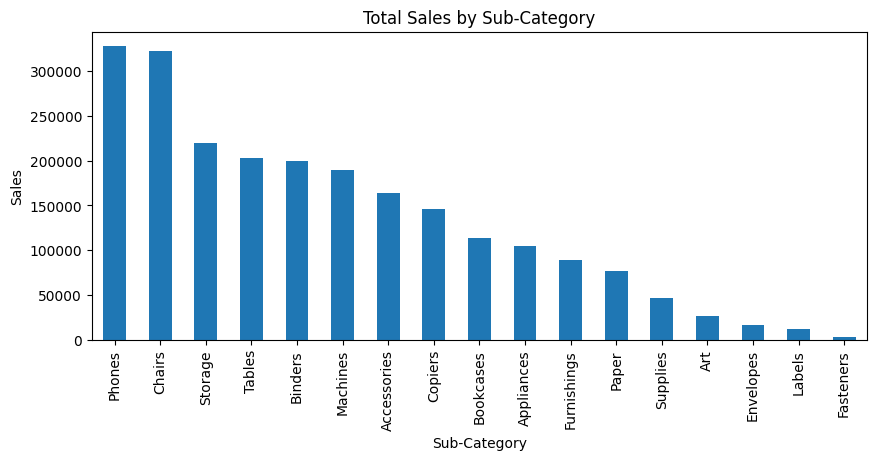

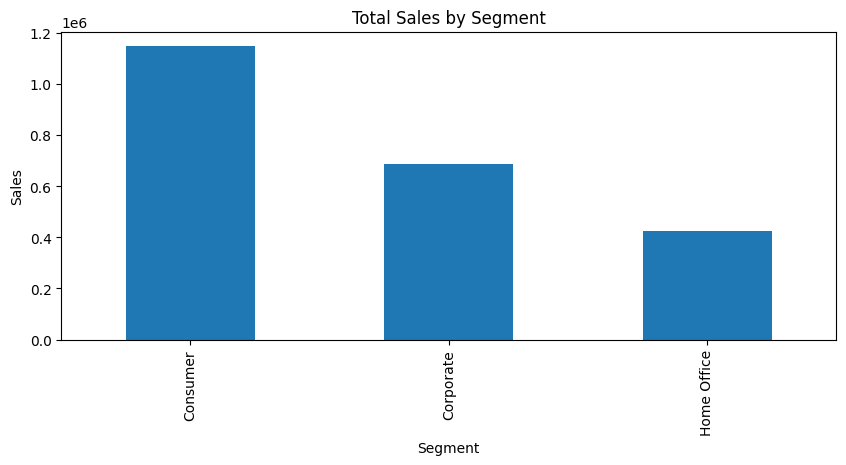

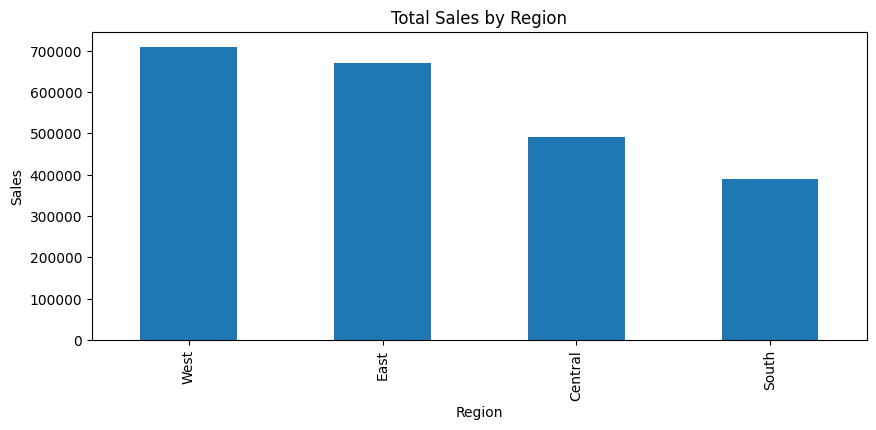

In [15]:
for col in ['Category', 'Sub-Category', 'Segment', 'Region']:
    plt.figure(figsize=(10,4))
    df.groupby(col)['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
    plt.title(f'Total Sales by {col}')
    plt.ylabel('Sales')
    plt.show()

 Total Sales by Category
Technology leads, followed by Furniture, then Office Supplies. This tells us where revenue concentration lies. Technology is the primary revenue driver, so forecasting accuracy for this category matters most to the business's bottom line, and category-level (not just overall).

 Total Sales by Sub-Category
Phones rank highest, with Fasteners lowest. This narrows the "Technology leads" finding down to a specific product driver "Phones". They are likely the single most important product line to get right in the forecast, while very low-value sub-categories like "Fasteners" contribute little and may not need individual forecasting attention.

 Total Sales by Segment
Consumer is the highest-revenue segment, with Home Office the lowest (Corporate presumably in between). This tells the us their core customer base is individual consumers rather than large corporate accounts, which should shape how demand drivers are interpreted (e.g., consumer buying patterns/holidays matter more than corporate budget cycles).

## 9. Correlation Heatmap

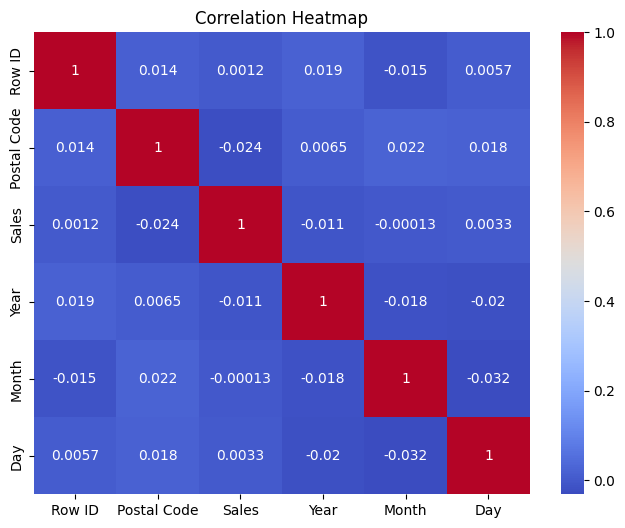

In [16]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

All correlation coefficients between the numeric fields are extremely close to zero (mostly in the ±0.01–0.03 range), with the diagonal of 1.0 simply confirming each variable perfectly correlates with itself. In practical terms, this means Sales shows no meaningful linear relationship with Row ID, Postal Code, Year, Month, or Day when measured this way.

No useful linear correlations exist among the raw numeric fields, and the meaningful sales drivers identified so far (month, day of week, category, segment, region) are categorical/cyclical patterns rather than linear numeric relationships

## 10. Stationarity Assessment: ADF Test 

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


The ADF test evaluates a specific statistical property (a unit root), and can pass even when a series has strong, regular seasonal structure because the repeating pattern isn't a random walk, it's predictable.

ADF Statistic: -4.42, p-value: 0.00028 → statistically significant, so the test rejects the presence of a unit root and technically labels the series "stationary."


## 11. Rolling Statistics


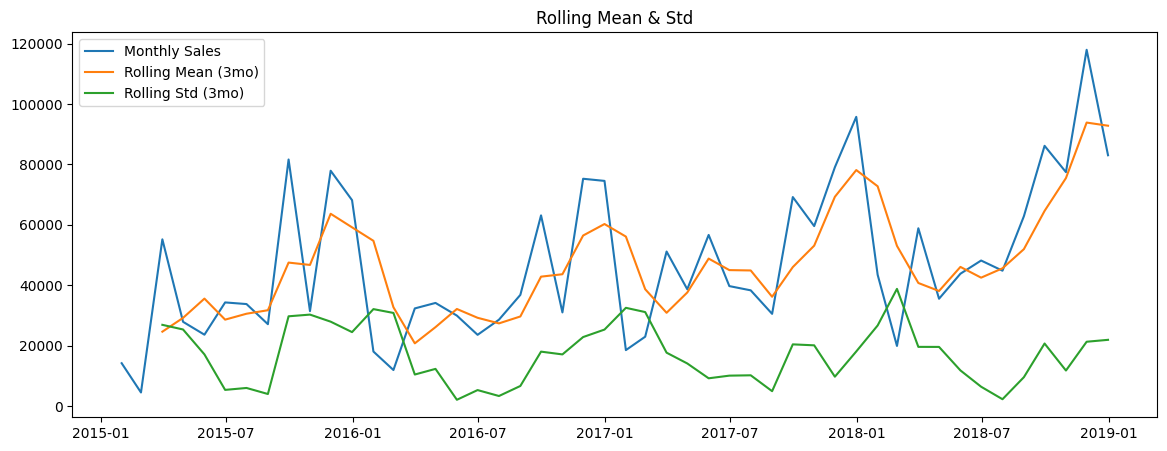

In [18]:
rolling_mean = monthly_sales.rolling(window=3).mean()
rolling_std = monthly_sales.rolling(window=3).std()

plt.figure(figsize=(14,5))
plt.plot(monthly_sales, label='Monthly Sales')
plt.plot(rolling_mean, label='Rolling Mean (3mo)')
plt.plot(rolling_std, label='Rolling Std (3mo)')
plt.legend()
plt.title('Rolling Mean & Std')
plt.show()

* Monthly Sales (blue): Sharp recurring peaks around each December (2015-12, 2016-12, 2017-12/2018-01, and a very large spike into 2018-12/2019 near ~118,000). Classic year-end/holiday seasonality, repeating across all 4 years.

* Rolling Mean, orange (3-month): Climbs steadily from roughly ~25,000 in mid-2015 to ~90,000+ by late 2018. This is a clear, sustained upward trend; the business is growing year over year, not fluctuating around a fixed level.
* Rolling Std, green (3-month): Also trends upward overall (low ~5,000–10,000 early on, reaching spikes of 20,000+ in later years), meaning volatility itself is increasing as sales grow, bigger swings around peak seasons in later years than in earlier years.


* Growth: Sales have grown consistently year-over-year (roughly 3-4x from 2015 to 2018-end levels based on rolling mean).

* Seasonality: Strong, repeating December peaks each year — plan inventory/staffing around this.
Rising volatility: Swings around peak season have gotten larger in absolute terms as the business has scaled forecast confidence intervals should widen for recent/future periods, not stay fixed.

